In [1]:
import pandas as pd 
import seaborn as sns
import numpy as np
from pathlib import Path

In [23]:
braindino_runs = list(Path('/common/ganesanv/tlab/runs/adni_benchmark/braindino').glob('run*'))
cp_runs = list(Path('/common/ganesanv/tlab/runs/adni_benchmark/continued_pretraining').glob('run*'))
ssl_finetune_runs = list(Path('/common/ganesanv/tlab/runs/adni_benchmark/ssl_finetune_intermediate').glob('run*'))


In [21]:
print(list(braindino_runs))

[PosixPath('/common/ganesanv/tlab/runs/adni_benchmark/braindino/run0'), PosixPath('/common/ganesanv/tlab/runs/adni_benchmark/braindino/run3'), PosixPath('/common/ganesanv/tlab/runs/adni_benchmark/braindino/run1'), PosixPath('/common/ganesanv/tlab/runs/adni_benchmark/braindino/run4'), PosixPath('/common/ganesanv/tlab/runs/adni_benchmark/braindino/run2'), PosixPath('/common/ganesanv/tlab/runs/adni_benchmark/braindino/run5')]


In [26]:
import json
def parse_metrics(runs_paths):
    aurocs = []
    f1s = []
    for path in list(runs_paths):
        with open(path / 'run_summary.json', 'r') as f:
            d = json.load(f)

            aurocs.append(d['metrics']['test']['auroc'])
            f1s.append(d['metrics']['test']['f1'])
    return aurocs, f1s

print(parse_metrics(braindino_runs))

([0.7712022367194781, 0.7894920782851818, 0.7868126747437093, 0.8041705498602051, 0.7809878844361603, 0.7879776328052192], [0.6578947368421053, 0.6792452830188679, 0.6748466257668712, 0.6787878787878788, 0.6756756756756757, 0.6578947368421053])


In [27]:
bd_aurocs, bd_f1s = parse_metrics(braindino_runs)
cp_aurocs, cp_f1s = parse_metrics(cp_runs)
ssl_aurocs, ssl_f1s = parse_metrics(ssl_finetune_runs)

df = pd.DataFrame(columns=["metric", "method", "value"])

df["method"] = ((["BrainDINO"] * len(bd_aurocs)) + (["Extended Pre-Training"] * len(cp_aurocs)) + (["3-D Aware Fine Tuning"] * len(ssl_aurocs))) * 2

df["metric"] = (["AUROC"] * (len(bd_aurocs) + len(cp_aurocs) + len(ssl_aurocs))) + (["F1"] * (len(bd_aurocs) + len(cp_aurocs) + len(ssl_aurocs)))

df['value'] = bd_aurocs + cp_aurocs + ssl_aurocs + bd_f1s + cp_f1s + ssl_f1s


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

F1_BrainDINO vs. F1_3-D Aware Fine Tuning: Mann-Whitney-Wilcoxon test two-sided, P_val:4.998e-03 U_stat=3.600e+01
F1_3-D Aware Fine Tuning vs. F1_Extended Pre-Training: Mann-Whitney-Wilcoxon test two-sided, P_val:4.329e-03 U_stat=3.500e+01
AUROC_BrainDINO vs. AUROC_3-D Aware Fine Tuning: Mann-Whitney-Wilcoxon test two-sided, P_val:1.515e-02 U_stat=3.300e+01
AUROC_3-D Aware Fine Tuning vs. AUROC_Extended Pre-Training: Mann-Whitney-Wilcoxon test two-sided, P_val:2.165e-03 U_stat=3.600e+01
F1_BrainDINO vs. F1_Extended Pre-Training: Mann-Whitney-Wilcoxon test two-sided, P_val:4.998e-03 U_stat=3.600e+01
AUROC_BrainDINO vs. AUROC_Extended Pre-Training: Mann-Whitney-Wilcoxon test two-sided, P_val:2.165e-03 U_stat=3.600e+01


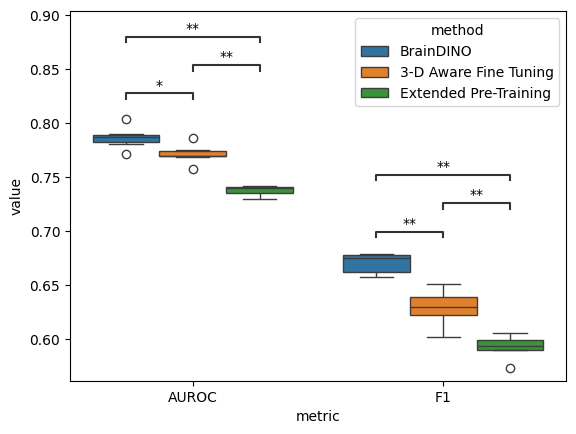

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
from statannotations.Annotator import Annotator 

# fig, ax = plt.subplots(1, 1, tight_layout=True)
hue_order = ["BrainDINO", "3-D Aware Fine Tuning", "Extended Pre-Training"]
ax = sns.boxplot(data=df, x='metric', y='value', hue='method',
hue_order=["BrainDINO", "3-D Aware Fine Tuning", "Extended Pre-Training"])

pairs = [(("AUROC", "BrainDINO"), ("AUROC", "3-D Aware Fine Tuning")), (("AUROC", "3-D Aware Fine Tuning"), ("AUROC", "Extended Pre-Training")), (("AUROC", "BrainDINO"), ("AUROC", "Extended Pre-Training"))]
pairs = pairs + [(("F1", "BrainDINO"), ("F1", "3-D Aware Fine Tuning")), (("F1", "3-D Aware Fine Tuning"), ("F1", "Extended Pre-Training")), (("F1", "BrainDINO"), ("F1", "Extended Pre-Training"))]
annotator = Annotator(ax, pairs, data=df, x='metric', y='value', hue='method', hue_order=hue_order)
annotator.configure(test='Mann-Whitney', text_format='star', )
annotator.apply_and_annotate()

plt.show()